# Caliana — Quickstart

Analysis of plant calcium imaging data, end-to-end on the bundled synthetic recording.

Each stage can be driven two ways:

- **Interactive PyQt widget** — `s.preview()`, `s.select_rois()`, `s.analyze()`. These open windows and block until you close them, so they are **skipped** when this notebook is run non-interactively (they need a display). Run them yourself after enabling the Qt event loop.
- **Headless API** — the same operations as plain calls, executed below with rendered plots.

Workflow: load → register → ROIs → ΔF/F → propagation → export.

In [ ]:
import sys; sys.path.insert(0, '../src')   # fallback if caliana isn't installed; prefer: pip install -e '.[all]'
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import caliana
print('caliana', caliana.__version__)

To use the interactive widgets, first enable the Qt event loop so windows don't freeze the kernel:

In [2]:
%gui qt

## 1. Load & downsample (Stage I)

`Session.from_file` reads a TIFF/nd2 stack and applies downsample-on-load parameters (here: average every 2 frames). Units are pixels and frame indices only.

In [ ]:
s = caliana.Session.from_file('../tests/data/synthetic_calcium_imaging.tif', temporal_step=1)
print('stack shape (T, Y, X):', s.data.shape)

**Interactive preview** — scrub/playback, contrast/colormap, and the normalized max-projection side by side:

In [4]:
s.preview()

Headless equivalent — a frame and the **normalized max-intensity projection** (which highlights where the signal ever gets bright, useful for placing ROIs):

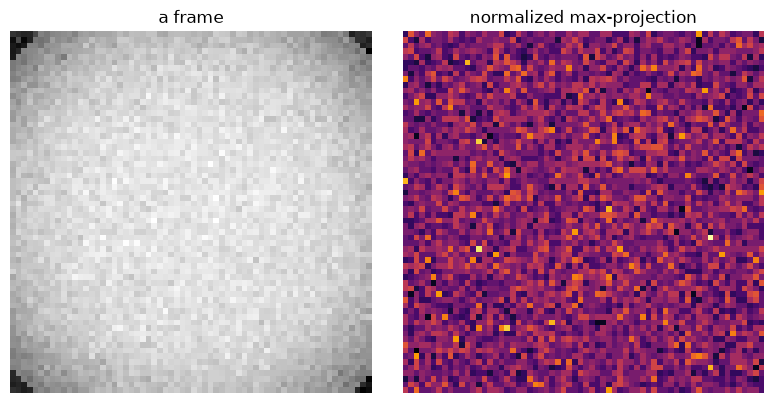

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(s.data[s.data.shape[0] // 2], cmap='gray')
ax[0].set_title('a frame'); ax[0].axis('off')
ax[1].imshow(s.max_projection(), cmap='inferno')
ax[1].set_title('normalized max-projection'); ax[1].axis('off')
plt.tight_layout()

## 2. Rigid registration (Stage II, optional)

Whole-frame rigid registration (translation + rotation) stabilizes leaf movement so static ROIs stay on the same tissue. Per-frame transforms are stored on the session, and once registered, ROIs/heatmap/traces use the stabilized stack automatically.

In [6]:
s.register(caliana.RegistrationMode.WHOLE_FRAME, reference='mean')
dxy = np.array([(t.dy, t.dx) for t in s.registration.transforms])
print('registration mode :', s.registration.mode.value)
print('max |dy|, |dx| (px):', np.round(np.abs(dxy).max(axis=0), 3))

registration mode : whole-frame
max |dy|, |dx| (px): [46.812 52.48 ]


> **Caveat — when *not* to register.** Intensity-based registration aligns whatever image structure it finds. On real leaf recordings that structure is stable tissue (veins/texture) and registration corrects genuine leaf motion. But **this synthetic clip has no real motion — its only structure is the calcium signal itself** (a blob growing from centre). So registration locks onto the *signal*, inventing transforms that smear bright pixels into ROIs and corrupt the onset timing. We therefore disable it for this particular dataset:

In [7]:
s.register(caliana.RegistrationMode.NONE)   # appropriate for this synthetic clip
print('registration mode :', s.registration.mode.value)

registration mode : none


## 3. ROIs & traces (Stage II)

**Interactive** — click the image to place fixed circle/square ROIs, drag to move, draw leaf boxes, and watch the trace preview update live:

In [8]:
s.select_rois()

[]

Headless equivalent — place the same ROIs programmatically (used for the rendered outputs below). Each ROI's trace is the mean intensity inside it per frame.

In [9]:
for center, label in [((32, 32), 'centre'), ((20, 20), 'mid'), ((12, 12), 'corner')]:
    s.add_roi(center=center, size=4, label=label)
traces = s.extract_traces()
print('traces shape (n_roi, T):', traces.raw.shape)

traces shape (n_roi, T): (3, 100)


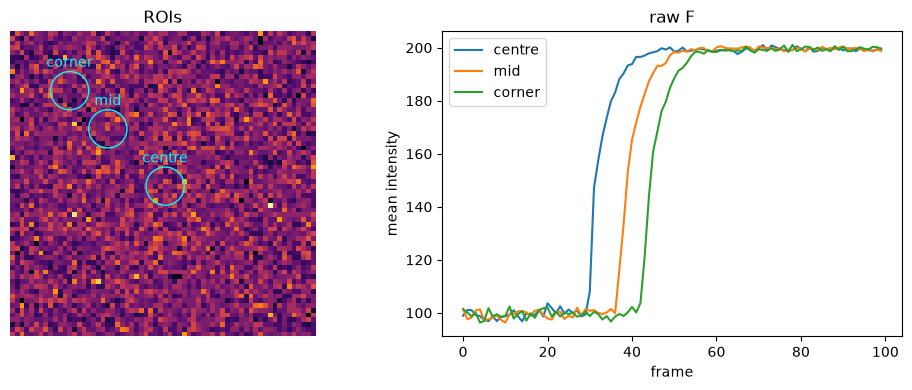

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(s.max_projection(), cmap='inferno')
for r in s.rois:
    ax[0].add_patch(plt.Circle((r.center[1], r.center[0]), r.size, fill=False, color='cyan'))
    ax[0].text(r.center[1], r.center[0] - r.size - 1, r.label, color='cyan', ha='center')
ax[0].set_title('ROIs'); ax[0].axis('off')
for i, label in enumerate(traces.labels):
    ax[1].plot(traces.raw[i], label=label)
ax[1].set_xlabel('frame'); ax[1].set_ylabel('mean intensity')
ax[1].set_title('raw F'); ax[1].legend()
plt.tight_layout()

## 4. ΔF/F (Stage III)

**Interactive** — the Stage III widget does baseline selection (first-N or a draggable window), ΔF/F, peak detection, event markers, and propagation in one place:

In [11]:
s.analyze()

{}

Headless equivalent — ΔF/F = (F − F0)/F0 with F0 = mean of the first 12 frames (a pre-stimulus baseline):

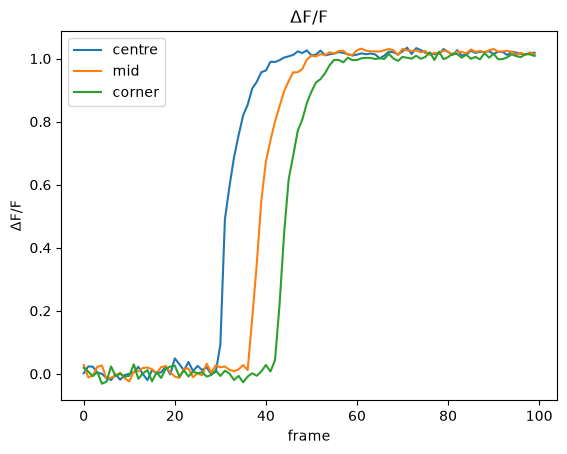

In [12]:
s.compute_dff(n=12)
for i, label in enumerate(s.traces.labels):
    plt.plot(s.traces.dff[i], label=label)
plt.xlabel('frame'); plt.ylabel('\u0394F/F'); plt.title('\u0394F/F'); plt.legend();

These are **step-like sustained** responses, so classic peak detection finds nothing (a monotonic rise to a plateau has no interior peak). For this signal shape the meaningful metric is **onset timing** — see the next section. Peak detection still earns its keep on transient/oscillatory data.

In [13]:
peaks = s.detect_peaks()
print('peak counts:', [p['count'] for p in peaks])

peak counts: [26, 28, 31]


## 5. Cross-ROI propagation

Detect each ROI's onset (half-max crossing) and fit onset time against ROI coordinates to get **speed (px/frame)**, **direction**, and the **source** (earliest) ROI. The staggered onsets below are the propagation signal.

In [14]:
res = s.cross_roi_propagation(signal='dff')
print('source (earliest):', s.traces.labels[res['source_roi']])
print('speed           : %.3g px/frame' % res['speed_px_per_frame'])
print('direction (dy,dx):', tuple(round(v, 3) for v in res['direction']))
for label, t in zip(s.traces.labels, res['onsets']):
    print('  onset %-7s %.2f' % (label, t))

source (earliest): centre
speed           : 2.16 px/frame
direction (dy,dx): (-0.707, -0.707)
  onset centre  31.17
  onset mid     38.77
  onset corner  44.29


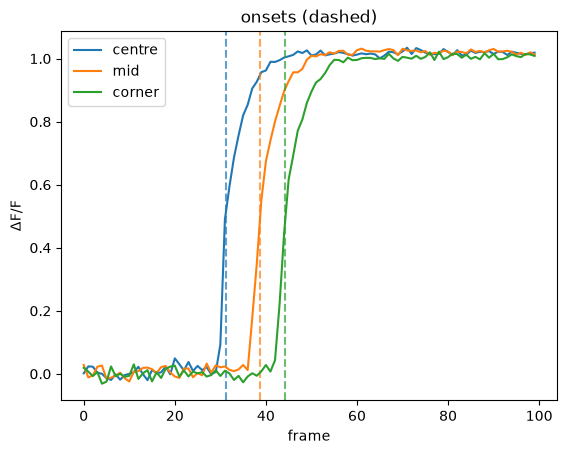

In [15]:
for i, label in enumerate(s.traces.labels):
    line, = plt.plot(s.traces.dff[i], label=label)
    plt.axvline(res['onsets'][i], color=line.get_color(), ls='--', alpha=0.7)
plt.xlabel('frame'); plt.ylabel('\u0394F/F'); plt.title('onsets (dashed)'); plt.legend();

## 6. Events & reproducible export

Mark optional stimulus events, then export per-ROI traces (CSV) and a provenance sidecar (JSON) recording every parameter so the analysis is reproducible.

In [16]:
import tempfile, os, json
s.timeline.add_event(15, label='stimulus')
out = tempfile.mkdtemp()
s.export_traces(os.path.join(out, 'traces.csv'))
s.export_provenance(os.path.join(out, 'provenance.json'))
print('traces.csv (head):')
print('\n'.join(open(os.path.join(out, 'traces.csv')).read().splitlines()[:4]))
print('\nprovenance.json:')
print(json.dumps(json.load(open(os.path.join(out, 'provenance.json'))), indent=2)[:700])

traces.csv (head):
frame,centre_F,centre_dFF,mid_F,mid_dFF,corner_F,corner_dFF
0,98.93877551020408,0.0016873859292675848,101.51020408163265,0.02819934195793361,101.3265306122449,0.019053809051414454
1,101.10204081632654,0.02358896656220955,97.61224489795919,-0.01128318202959455,100.14285714285714,0.007149454383744345
2,101.0204081632653,0.022762491821343715,98.20408163265306,-0.005288453256619129,98.73469387755102,-0.007012622720897593

provenance.json:
{
  "source": {
    "path": "../synthetic_calcium_imaging.tif",
    "import_params": {
      "start": 0,
      "end": null,
      "temporal_step": 1,
      "spatial_step": 1,
      "spatial_window": null,
      "channel": 0
    }
  },
  "registration": {
    "mode": "none",
    "reference": "mean",
    "leaf_regions": []
  },
  "rois": [
    {
      "center": [
        32,
        32
      ],
      "size": 4,
      "shape": "circle",
      "label": "centre",
      "leaf_region": null
    },
    {
      "center": [
        20,
        20

## Recap

Interactive entry points (after `%gui qt`): `s.preview()` (Stage I), `s.select_rois()` (Stage II), `s.analyze()` (Stage III). Each reads and writes the same `Session`, so you can freely mix widgets and API calls.